### Ucitavanje podataka iz tabele

In [1]:
import pandas as pd
import numpy as np
import math

def load_itu1546_land_600mhz_csv(
    file_path: str,
    skiprows: int = 4
):
    column_names = [
        "d_km", "h_10", "h_20", "h_37_5", "h_75",
        "h_150", "h_300", "h_600", "h_1200", "max_fs"
    ]

    df = pd.read_csv(file_path, skiprows=skiprows, names=column_names)
    df = df.dropna(subset=["d_km"]).copy()
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["d_km"]).copy()

    df = df.sort_values("d_km")
    df = df.set_index("d_km")

    d_grid = df.index.to_numpy(dtype=float)
    E10_grid = df["h_10"].to_numpy(dtype=float)
    E20_grid = df["h_20"].to_numpy(dtype=float)
    Emax_grid = df["max_fs"].to_numpy(dtype=float)

    return d_grid, E10_grid, E20_grid, Emax_grid, df


In [2]:
def interp_log_distance(d_km: float, d_grid: np.ndarray, values: np.ndarray) -> float:
    d_km = float(d_km)

    if d_km <= float(d_grid[0]):
        return float(values[0])
    if d_km >= float(d_grid[-1]):
        return float(values[-1])

    idx = int(np.searchsorted(d_grid, d_km) - 1)
    dinf = float(d_grid[idx])
    dsup = float(d_grid[idx + 1])
    vinf = float(values[idx])
    vsup = float(values[idx + 1])

    t = math.log10(d_km / dinf) / math.log10(dsup / dinf)
    return vinf + (vsup - vinf) * t

def E10_at_d(d_km: float, d_grid: np.ndarray, E10_grid: np.ndarray) -> float:
    return interp_log_distance(d_km, d_grid, E10_grid)

def E20_at_d(d_km: float, d_grid: np.ndarray, E20_grid: np.ndarray) -> float:
    return interp_log_distance(d_km, d_grid, E20_grid)

def Efs_at_d(d_km: float, d_grid: np.ndarray, Efs_grid: np.ndarray) -> float:
    return interp_log_distance(d_km, d_grid, Efs_grid)

In [3]:
def formula_4_E(h1_m: float, Ezero: float, E10: float) -> float:
    h1_m = float(h1_m)
    if not (0.0 <= h1_m <= 10.0):
        raise ValueError("formula_4_E je samo za 0 <= h1 <= 10 m.")
    return float(Ezero) + 0.1 * h1_m * (float(E10) - float(Ezero))

In [4]:
def formula_5_Ezero(E10: float, C1020: float, Ch1neg10: float) -> float:
    return float(E10) + 0.5 * (float(C1020) + float(Ch1neg10))

In [5]:
def formula_6_C1020(E20: float, E10: float) -> float:
    return -(float(E20) - float(E10))

In [6]:
KV_BY_FREQ_MHZ = {
    100.0: 1.35,
    600.0: 3.31,
    2000.0: 6.00
}

def formula_7_theta_eff_deg(h1_m: float) -> float:
    return math.degrees(math.atan(-float(h1_m) / 9000.0))

def formula_7_nu(h1_m: float, f_mhz: float = 600.0) -> float:
    f_mhz = float(f_mhz)
    if f_mhz not in KV_BY_FREQ_MHZ:
        raise ValueError(f"Nema Kv za f={f_mhz} MHz. Dozvoljeno: {list(KV_BY_FREQ_MHZ.keys())}")
    Kv = KV_BY_FREQ_MHZ[f_mhz]
    theta = formula_7_theta_eff_deg(h1_m)
    return Kv * theta

def formula_7_J(nu: float) -> float:
    nu = float(nu)
    x = nu - 0.1
    return 6.9 + 20.0 * math.log10(math.sqrt(x*x + 1.0) + x)


def formula_7_Ch1_db(h1_m: float, f_mhz: float = 600.0) -> float:
    nu = formula_7_nu(h1_m, f_mhz=f_mhz)
    return 6.03 - formula_7_J(nu)

In [7]:
def E0_from_formulas_4_to_7(
    d_km: float,
    h1_m: float,
    d_grid: np.ndarray,
    E10_grid: np.ndarray,
    E20_grid: np.ndarray,
    Efs_grid: np.ndarray | None = None,
    f_mhz: float = 600.0,
    clamp_to_free_space: bool = True
) -> float:
    d_km = float(d_km)
    h1_m = float(h1_m)

    if not (0.0 <= h1_m <= 10.0):
        raise ValueError("Ovaj wrapper je za 0 <= h1 <= 10 m.")

    E10 = E10_at_d(d_km, d_grid, E10_grid)
    E20 = E20_at_d(d_km, d_grid, E20_grid)

    C1020 = formula_6_C1020(E20, E10)
    Ch1neg10 = formula_7_Ch1_db(-10.0, f_mhz=f_mhz)
    Ezero = formula_5_Ezero(E10, C1020, Ch1neg10)
    E = formula_4_E(h1_m, Ezero, E10)
    if clamp_to_free_space and (Efs_grid is not None):
        Efs = Efs_at_d(d_km, d_grid, Efs_grid)
        E = min(E, Efs)

    return float(E)


In [8]:
H1_GRID = np.array([10.0, 20.0, 37.5, 75.0, 150.0, 300.0, 600.0, 1200.0], dtype=float)
H1_COLS = ["h_10", "h_20", "h_37_5", "h_75", "h_150", "h_300", "h_600", "h_1200"]

def E0_for_h_ge_10_from_table(
    d_km: float,
    h1_m: float,
    d_grid: np.ndarray,
    df: "pd.DataFrame",
    Efs_grid: np.ndarray | None = None,
    clamp_to_free_space: bool = True
) -> float:
    d_km = float(d_km)
    h1_m = float(h1_m)
    if h1_m < 10.0:
        raise ValueError("Ova funkcija je samo za h1 >= 10m.")

    def E_at_hcol(col_name: str) -> float:
        values = df[col_name].to_numpy(dtype=float)
        return interp_log_distance(d_km, d_grid, values)

    if h1_m <= H1_GRID[0]:
        E = E_at_hcol(H1_COLS[0])
    elif h1_m >= H1_GRID[-1]:
        E = E_at_hcol(H1_COLS[-1])
    else:
        exact = np.where(np.isclose(H1_GRID, h1_m))[0]
        if len(exact) > 0:
            E = E_at_hcol(H1_COLS[int(exact[0])])
        else:
            j = int(np.searchsorted(H1_GRID, h1_m) - 1)
            hinf = float(H1_GRID[j])
            hsup = float(H1_GRID[j + 1])
            Einf = E_at_hcol(H1_COLS[j])
            Esup = E_at_hcol(H1_COLS[j + 1])

            t = math.log10(h1_m / hinf) / math.log10(hsup / hinf)
            E = Einf + (Esup - Einf) * t

    if clamp_to_free_space and (Efs_grid is not None):
        Efs = Efs_at_d(d_km, d_grid, Efs_grid)
        E = min(E, Efs)
    return float(E)


In [9]:
def E0_600mhz_any_h1(
    d_km: float,
    h1_m: float,
    d_grid: np.ndarray,
    E10_grid: np.ndarray,
    E20_grid: np.ndarray,
    Efs_grid: np.ndarray,
    df: "pd.DataFrame",
    clamp_to_free_space: bool = True
) -> float:
    d_km = float(d_km)
    h1_m = float(h1_m)

    if not (1.0 <= d_km <= 1000.0):
        raise ValueError("d mora biti u opsegu 1..1000 km.")
    if not (0.0 <= h1_m <= 1200.0):
        raise ValueError("h1 mora biti u opsegu 0..1200 m.")

    if h1_m < 10.0:
        return E0_from_formulas_4_to_7(
            d_km=d_km,
            h1_m=h1_m,
            d_grid=d_grid,
            E10_grid=E10_grid,
            E20_grid=E20_grid,
            Efs_grid=Efs_grid,
            f_mhz=600.0,
            clamp_to_free_space=clamp_to_free_space
        )
    else:
        return E0_for_h_ge_10_from_table(
            d_km=d_km,
            h1_m=h1_m,
            d_grid=d_grid,
            df=df,
            Efs_grid=Efs_grid,
            clamp_to_free_space=clamp_to_free_space
        )

In [10]:
def build_train_test_dataset_inverse(
    E0_func,
    d_grid: np.ndarray,
    h1_train_tab: list[float], h1_test_tab: list[float],
    h1_train_small: list[float], h1_test_small: list[float],
    n_rand_train_small: int = 300, n_rand_test_small: int = 50,
    seed: int = 0
):
    rng = np.random.default_rng(seed)
    X_train, y_train = [], []

    for h1 in h1_train_tab:
        for d in d_grid:
            E0 = E0_func(float(d), float(h1))
            X_train.append([float(h1), float(E0)])
            y_train.append(float(d))

    for h1 in h1_train_small:
        ds = 10 ** rng.uniform(np.log10(1.0), np.log10(1000.0), size=n_rand_train_small)
        for d in ds:
            E0 = E0_func(float(d), float(h1))
            X_train.append([float(h1), float(E0)])
            y_train.append(float(d))

    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    X_test, y_test = [], []

    for h1 in h1_test_tab:
        for d in d_grid:
            E0 = E0_func(float(d), float(h1))
            X_test.append([float(h1), float(E0)])
            y_test.append(float(d))

    for h1 in h1_test_small:
        ds = 10 ** rng.uniform(np.log10(1.0), np.log10(1000.0), size=n_rand_test_small)
        for d in ds:
            E0 = E0_func(float(d), float(h1))
            X_test.append([float(h1), float(E0)])
            y_test.append(float(d))

    X_test = np.asarray(X_test, dtype=float)
    y_test = np.asarray(y_test, dtype=float)

    return X_train, y_train, X_test, y_test

In [11]:
csv_path = "ITU1546 TABULATED CURVES-50percent-Land-600MHz(600MHz).csv"
d_grid, E10g, E20g, Efs, df = load_itu1546_land_600mhz_csv(csv_path)

E0_func = lambda d, h: E0_600mhz_any_h1(
    d_km=d,
    h1_m=h,
    d_grid=d_grid,
    E10_grid=E10g,
    E20_grid=E20g,
    Efs_grid=Efs,
    df=df,
    clamp_to_free_space=True
)

h1_train_tab   = [10.0, 20, 37.5, 75.0, 150.0, 300.0, 600.0, 1200.0]
h1_test_tab    = [15.0, 25.0, 250.0, 800.0]

h1_train_small = [0.1, 2.0, 5.0, 8.0]
h1_test_small  = [1.0, 3.0, 7.0]

X_train_raw, y_train_raw, X_test_raw, y_test_raw = build_train_test_dataset_inverse(
    E0_func=E0_func,
    d_grid=d_grid,
    h1_train_tab=h1_train_tab,
    h1_test_tab=h1_test_tab,
    h1_train_small=h1_train_small,
    h1_test_small=h1_test_small,
    n_rand_train_small=700,
    n_rand_test_small=200,
    seed=0
)

print("X_train_raw:", X_train_raw.shape, "y_train_raw:", y_train_raw.shape)
print("X_test_raw :", X_test_raw.shape,  "y_test_raw :", y_test_raw.shape)


X_train_raw: (3424, 2) y_train_raw: (3424,)
X_test_raw : (912, 2) y_test_raw : (912,)


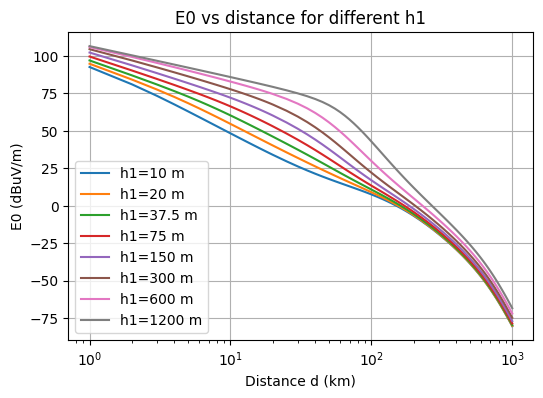

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_E0_curves(E0_func, h_list, d_grid):
    plt.figure(figsize=(6,4))
    
    for h in h_list:
        E_vals = [E0_func(float(d), float(h)) for d in d_grid]
        plt.plot(d_grid, E_vals, label=f"h1={h} m")

    plt.xscale("log")
    plt.xlabel("Distance d (km)")
    plt.ylabel("E0 (dBuV/m)")
    plt.title("E0 vs distance for different h1")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_E0_curves(
    E0_func,
    h_list=[10, 20, 37.5, 75, 150, 300, 600, 1200],
    d_grid=d_grid
)

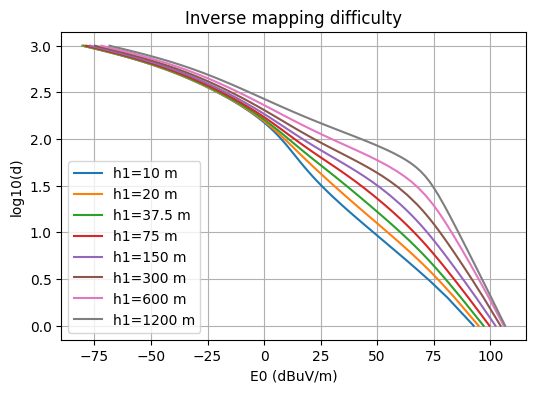

In [13]:
def plot_inverse_view(E0_func, h_list, d_grid):
    plt.figure(figsize=(6,4))
    
    for h in h_list:
        E_vals = np.array([E0_func(float(d), float(h)) for d in d_grid])
        plt.plot(E_vals, np.log10(d_grid), label=f"h1={h} m")

    plt.xlabel("E0 (dBuV/m)")
    plt.ylabel("log10(d)")
    plt.title("Inverse mapping difficulty")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_inverse_view(
    E0_func,
    h_list=[10, 20, 37.5, 75, 150, 300, 600, 1200],
    d_grid=d_grid
)

In [14]:
import numpy as np

def add_E0_rel_feature(X_raw: np.ndarray, E0_func, d_ref: float = 1.0) -> np.ndarray:
    """
    X_raw: shape (N, 2) = [h1, E0]
    Vraća X_feat: shape (N, 3) = [h1, E0, E0_rel]
    gde je E0_rel = E0 - E0_func(d_ref, h1)
    """
    h = X_raw[:, 0].astype(float)
    E0 = X_raw[:, 1].astype(float)

    E0_ref = np.array([E0_func(float(d_ref), float(hh)) for hh in h], dtype=float)
    E0_rel = E0 - E0_ref

    return np.column_stack([h, E0, E0_rel])

In [15]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X_train_feat = X_train_raw.copy()
X_test_feat  = X_test_raw.copy()

# log transform samo na h1 (prva kolona)
X_train_feat[:, 0] = np.log1p(X_train_feat[:, 0])
X_test_feat[:, 0]  = np.log1p(X_test_feat[:, 0])

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train_feat)
X_test  = scaler_X.transform(X_test_feat)

y_train_log = np.log10(y_train_raw)
y_test_log  = np.log10(y_test_raw)

y_mean = y_train_log.mean()
y_std  = y_train_log.std()

y_train = (y_train_log - y_mean) / y_std
y_test  = (y_test_log  - y_mean) / y_std

print("Normalizacija završena (X scaled, y = log10(d) standardized).")
print("Normalizacija završena.")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("y_mean:", y_mean, "y_std:", y_std)

Normalizacija završena (X scaled, y = log10(d) standardized).
Normalizacija završena.
X_train: (3424, 2) X_test: (912, 2)
y_train: (3424,) y_test: (912,)
y_mean: 1.5813567666799135 y_std: 0.8751990075110729


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def compute_metrics(y_true, y_pred, rel_floor_km: float = 10.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    err = y_pred - y_true
    abs_err = np.abs(err)

    denom = np.maximum(np.abs(y_true), float(rel_floor_km))
    rel_err = abs_err / denom

    ATE = np.mean(abs_err)
    WCE = np.max(abs_err)
    ATE_rel = 100.0 * np.mean(rel_err)
    WCE_rel = 100.0 * np.max(rel_err)

    if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        r = np.nan
    else:
        r = float(np.corrcoef(y_true, y_pred)[0, 1])

    worst_idx = int(np.argmax(abs_err))

    return {
        "ATE": float(ATE),
        "WCE": float(WCE),
        "ATE_rel_pct": float(ATE_rel),
        "WCE_rel_pct": float(WCE_rel),
        "r": r,
        "worst": {
            "idx": worst_idx,
            "y_true": float(y_true[worst_idx]),
            "y_pred": float(y_pred[worst_idx]),
            "abs_err": float(abs_err[worst_idx]),
            "rel_err_pct": float(100.0 * rel_err[worst_idx]),
        }
    }

In [17]:
hidden_layer_options = [
    (16, 16),
    (32, 32),
    # (32,32,16),
    # (32,16,8),
]

activation_options = ["tanh"]
solver_options = ["adam"]
learning_rate_init_options = [3e-4, 4e-4, 5e-4, 6e-4, 8e-4]
alpha_options = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4]
batch_size_options = [16, 8]


In [18]:
from sklearn.neural_network import MLPRegressor

results = []
model_counter = 0

for hidden_layers in hidden_layer_options:
    for activation in activation_options:
        for solver in solver_options:
            for lr in learning_rate_init_options:
                for alpha in alpha_options:
                    for batch_size in batch_size_options:
                        model_counter += 1
                        name = (
                            f"new_MLP_{model_counter}_"
                            f"L{'-'.join(str(u) for u in hidden_layers)}_"
                            f"{activation}_"
                            f"{solver}_"
                            f"lr{lr}_"
                            f"alpha{alpha}_"
                            f"bs{batch_size}"
                        )

                        mlp = MLPRegressor(
                            hidden_layer_sizes=hidden_layers,
                            activation=activation,
                            solver=solver,
                            learning_rate_init=lr,
                            alpha=alpha,
                            batch_size=batch_size,
                            max_iter=5000,
                            tol=1e-6,
                            early_stopping=True,
                            validation_fraction=0.15,
                            n_iter_no_change=80,
                            random_state=0
                        )

                        mlp.fit(X_train, y_train)

                        y_train_pred_norm = mlp.predict(X_train)
                        y_test_pred_norm  = mlp.predict(X_test)

                        y_train_pred_log = y_train_pred_norm * y_std + y_mean
                        y_test_pred_log  = y_test_pred_norm  * y_std + y_mean

                        y_train_pred = 10 ** y_train_pred_log
                        y_test_pred  = 10 ** y_test_pred_log

                        # y_train_pred = np.clip(y_train_pred, 1.0, 1000.0)
                        # y_test_pred  = np.clip(y_test_pred, 1.0, 1000.0)

                        metrics_train = compute_metrics(y_train_raw, y_train_pred, rel_floor_km=10.0)
                        metrics_test  = compute_metrics(y_test_raw,  y_test_pred,  rel_floor_km=10.0)

                        print("\n==============================================")
                        print("Trening modela:", name)
                        print("Train metrics:", metrics_train)
                        print("Test metrics:", metrics_test)

                        results.append({
                            "name": name,
                            "config": {
                                "hidden_layers": hidden_layers,
                                "activation": activation,
                                "solver": solver,
                                "lr": lr,
                                "alpha": alpha,
                                "batch_size": batch_size
                            },
                            "model": mlp,
                            "metrics_train": metrics_train,
                            "metrics_test": metrics_test
                        })

print(f"\nUkupno istreniranih modela: {len(results)}")



Trening modela: new_MLP_1_L16-16_tanh_adam_lr0.0003_alpha1e-06_bs16
Train metrics: {'ATE': 1.0750042555073496, 'WCE': 23.070927183334675, 'ATE_rel_pct': 0.7028582740215441, 'WCE_rel_pct': 8.397539483549288, 'r': 0.9999490800115852, 'worst': {'idx': 2019, 'y_true': 986.7391739167446, 'y_pred': 963.6682467334099, 'abs_err': 23.070927183334675, 'rel_err_pct': 2.3380978269827226}}
Test metrics: {'ATE': 1.3650224105307238, 'WCE': 18.297627808762172, 'ATE_rel_pct': 0.8489427828281862, 'WCE_rel_pct': 5.807046529612545, 'r': 0.9999383237121898, 'worst': {'idx': 691, 'y_true': 965.3634293552913, 'y_pred': 947.0658015465291, 'abs_err': 18.297627808762172, 'rel_err_pct': 1.8954134010423482}}

Trening modela: new_MLP_2_L16-16_tanh_adam_lr0.0003_alpha1e-06_bs8
Train metrics: {'ATE': 0.9448184919298566, 'WCE': 20.41998943732017, 'ATE_rel_pct': 0.6336394337714016, 'WCE_rel_pct': 7.293844286218221, 'r': 0.999959354999774, 'worst': {'idx': 2019, 'y_true': 986.7391739167446, 'y_pred': 966.3191844794244

In [19]:
results_sorted = sorted(results, key=lambda r: r["metrics_test"]["ATE"])

print("\n=== REZIME MODELA (sortirano po ATE na test skupu) ===")
for r in results_sorted:
    mt = r["metrics_test"]
    print(
        f"{r['name']}: "
        f"ATE={mt['ATE']:.3f} km, "
        f"WCE={mt['WCE']:.3f} km, "
        f"ATE_rel={mt['ATE_rel_pct']:.2f} %, "
        f"WCE_rel={mt['WCE_rel_pct']:.2f} %, "
        f"r={mt['r']:.4f}"
    )

best3 = results_sorted[:3]
print("\nTOP 3:", [b["name"] for b in best3])



=== REZIME MODELA (sortirano po ATE na test skupu) ===
new_MLP_82_L32-32_tanh_adam_lr0.0006_alpha1e-06_bs8: ATE=0.622 km, WCE=11.144 km, ATE_rel=0.42 %, WCE_rel=4.30 %, r=1.0000
new_MLP_52_L32-32_tanh_adam_lr0.0003_alpha1e-06_bs8: ATE=0.664 km, WCE=6.645 km, ATE_rel=0.49 %, WCE_rel=3.87 %, r=1.0000
new_MLP_62_L32-32_tanh_adam_lr0.0004_alpha1e-06_bs8: ATE=0.739 km, WCE=6.228 km, ATE_rel=0.47 %, WCE_rel=3.88 %, r=1.0000
new_MLP_66_L32-32_tanh_adam_lr0.0004_alpha1e-05_bs8: ATE=0.741 km, WCE=8.354 km, ATE_rel=0.51 %, WCE_rel=3.38 %, r=1.0000
new_MLP_56_L32-32_tanh_adam_lr0.0003_alpha1e-05_bs8: ATE=0.755 km, WCE=8.326 km, ATE_rel=0.55 %, WCE_rel=3.38 %, r=1.0000
new_MLP_92_L32-32_tanh_adam_lr0.0008_alpha1e-06_bs8: ATE=0.757 km, WCE=7.687 km, ATE_rel=0.53 %, WCE_rel=3.61 %, r=1.0000
new_MLP_72_L32-32_tanh_adam_lr0.0005_alpha1e-06_bs8: ATE=0.771 km, WCE=8.189 km, ATE_rel=0.55 %, WCE_rel=3.27 %, r=1.0000
new_MLP_54_L32-32_tanh_adam_lr0.0003_alpha3e-06_bs8: ATE=0.792 km, WCE=12.716 km, ATE_rel

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def predict_km(mlp, X_norm, y_mean, y_std, clip_min=1.0, clip_max=1000.0):
    y_pred_norm = mlp.predict(X_norm)
    y_pred_log = y_pred_norm * y_std + y_mean
    d_pred_km = 10 ** y_pred_log
    return np.clip(d_pred_km, clip_min, clip_max)

def plot_scatter_km(y_true_km, y_pred_km, title, filename):
    y_true_km = np.asarray(y_true_km, dtype=float)
    y_pred_km = np.asarray(y_pred_km, dtype=float)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_km, y_pred_km, s=6, alpha=0.5)
    mn = float(min(np.min(y_true_km), np.min(y_pred_km)))
    mx = float(max(np.max(y_true_km), np.max(y_pred_km)))
    plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    plt.xlabel("d referentno [km]")
    plt.ylabel("d model (NN) [km]")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print("Saved:", filename)

def plot_abs_error_vs_d(y_true_km, y_pred_km, title, filename):
    y_true_km = np.asarray(y_true_km, dtype=float)
    y_pred_km = np.asarray(y_pred_km, dtype=float)
    abs_err = np.abs(y_pred_km - y_true_km)

    plt.figure(figsize=(7, 5))
    plt.scatter(y_true_km, abs_err, s=6, alpha=0.5)
    plt.xlabel("d referentno [km]")
    plt.ylabel("|greška| [km]")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print("Saved:", filename)

def plot_rel_error_vs_d(y_true_km, y_pred_km, rel_floor_km=10.0, title="", filename=""):
    y_true_km = np.asarray(y_true_km, dtype=float)
    y_pred_km = np.asarray(y_pred_km, dtype=float)
    abs_err = np.abs(y_pred_km - y_true_km)
    denom = np.maximum(y_true_km, float(rel_floor_km))
    rel_err_pct = 100.0 * abs_err / denom

    plt.figure(figsize=(7, 5))
    plt.scatter(y_true_km, rel_err_pct, s=6, alpha=0.5)
    plt.xlabel("d referentno [km]")
    plt.ylabel(f"relativna greška [%] (denom>= {rel_floor_km} km)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print("Saved:", filename)

def plot_cdf_abs_error(models_named_preds, title, filename):

    plt.figure(figsize=(7, 5))

    for name, abs_err in models_named_preds:
        abs_err = np.sort(np.asarray(abs_err, dtype=float))
        y = np.linspace(0, 1, len(abs_err), endpoint=True)
        plt.plot(abs_err, y, label=name)

    plt.xlabel("|greška| [km]")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    print("Saved:", filename)

def plot_d_vs_E0_curves_for_model(
    mlp, model_name, E0_func, scaler_X, y_mean, y_std,
    h_values=(5.0, 75.0, 20.0, 1200.0),
    d_min=1.0, d_max=1000.0, n_points=400
):
    d_true = np.linspace(d_min, d_max, n_points)

    for h1 in h_values:
        E0 = np.array([E0_func(float(d), float(h1)) for d in d_true], dtype=float)

        X_curve = np.column_stack([np.full_like(E0, float(h1)), E0])
        X_curve[:, 0] = np.log1p(X_curve[:, 0])
        X_curve_norm = scaler_X.transform(X_curve)

        d_pred = predict_km(mlp, X_curve_norm, y_mean, y_std)

        plt.figure(figsize=(7, 5))
        plt.plot(E0, d_true, linewidth=2, label="Referentno (ITU)")
        plt.plot(E0, d_pred, linewidth=2, linestyle="--", label="Model NN")
        plt.xlabel("E0 [dBµV/m]")
        plt.ylabel("d [km]")
        plt.title(f"d(E0) za h1={h1} m — {model_name}")
        plt.grid(True)
        plt.legend()
        plt.gca().invert_xaxis()  # uobičajeno za ove krive
        plt.tight_layout()

        fname = f"curve_{model_name}_h{str(h1).replace('.','_')}.png"
        plt.savefig(fname, dpi=300)
        plt.close()
        print("Saved:", fname)

cdf_list = []

for res in best3:
    name = res["name"]
    mlp = res["model"]

    y_train_pred_km = predict_km(mlp, X_train, y_mean, y_std)
    y_test_pred_km  = predict_km(mlp, X_test,  y_mean, y_std)

    plot_scatter_km(
        y_train_raw, y_train_pred_km,
        title=f"Train scatter – {name}",
        filename=f"scatter_train_{name}.png"
    )
    plot_scatter_km(
        y_test_raw, y_test_pred_km,
        title=f"Test scatter – {name}",
        filename=f"scatter_test_{name}.png"
    )

    plot_abs_error_vs_d(
        y_test_raw, y_test_pred_km,
        title=f"|greška| vs d (TEST) – {name}",
        filename=f"abs_error_vs_d_test_{name}.png"
    )
    plot_rel_error_vs_d(
        y_test_raw, y_test_pred_km,
        rel_floor_km=10.0,
        title=f"Relativna greška vs d (TEST) – {name}",
        filename=f"rel_error_vs_d_test_{name}.png"
    )

    abs_err = np.abs(y_test_pred_km - y_test_raw)
    cdf_list.append((name, abs_err))

plot_cdf_abs_error(
    cdf_list,
    title="CDF apsolutne greške na TEST skupu (Top-3 modeli)",
    filename="cdf_abs_error_top3_test.png"
)

h_values_to_plot = (5.0, 75.0, 20.0, 1200.0)

for res in best3:
    name = res["name"]
    mlp = res["model"]
    plot_d_vs_E0_curves_for_model(
        mlp=mlp,
        model_name=name,
        E0_func=E0_func,
        scaler_X=scaler_X,
        y_mean=y_mean,
        y_std=y_std,
        h_values=h_values_to_plot
    )


Saved: scatter_train_new_MLP_82_L32-32_tanh_adam_lr0.0006_alpha1e-06_bs8.png
Saved: scatter_test_new_MLP_82_L32-32_tanh_adam_lr0.0006_alpha1e-06_bs8.png
Saved: abs_error_vs_d_test_new_MLP_82_L32-32_tanh_adam_lr0.0006_alpha1e-06_bs8.png
Saved: rel_error_vs_d_test_new_MLP_82_L32-32_tanh_adam_lr0.0006_alpha1e-06_bs8.png
Saved: scatter_train_new_MLP_52_L32-32_tanh_adam_lr0.0003_alpha1e-06_bs8.png
Saved: scatter_test_new_MLP_52_L32-32_tanh_adam_lr0.0003_alpha1e-06_bs8.png
Saved: abs_error_vs_d_test_new_MLP_52_L32-32_tanh_adam_lr0.0003_alpha1e-06_bs8.png
Saved: rel_error_vs_d_test_new_MLP_52_L32-32_tanh_adam_lr0.0003_alpha1e-06_bs8.png
Saved: scatter_train_new_MLP_62_L32-32_tanh_adam_lr0.0004_alpha1e-06_bs8.png
Saved: scatter_test_new_MLP_62_L32-32_tanh_adam_lr0.0004_alpha1e-06_bs8.png
Saved: abs_error_vs_d_test_new_MLP_62_L32-32_tanh_adam_lr0.0004_alpha1e-06_bs8.png
Saved: rel_error_vs_d_test_new_MLP_62_L32-32_tanh_adam_lr0.0004_alpha1e-06_bs8.png
Saved: cdf_abs_error_top3_test.png
Saved: c